# Predykcja odejść klientów przy wykorzystaniu sieci neuronowych

In [1]:
import pandas as pd

df = pd.read_csv("data/preprocessed_telco_customer_churn.csv", index_col=0)
df.head()

,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,device_protection,...,internet_service_fiber_optic,internet_service_no,contract_month_to_month,contract_one_year,contract_two_year,payment_method_bank_transfer_automatic,payment_method_credit_card_automatic,payment_method_electronic_check,payment_method_mailed_check,churn
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,1,0,0
5575-GNVDE,1,0,0,0,34,1,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
3668-QPYBK,1,0,0,0,2,1,0,1,1,0,...,0,0,1,0,0,0,0,0,1,1
7795-CFOCW,1,0,0,0,45,0,0,1,0,1,...,0,0,0,1,0,1,0,0,0,0
9237-HQITU,0,0,0,0,2,1,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1


#### Podział zbioru na dane treningowe i testowe oraz skalowanie kolumn numerycznych

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=55, stratify=y)

cols_to_scale = ['tenure', 'monthly_charges', 'total_charges']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

### Klasyfikator MLP (Multilayer Perceptron)

Zaawansowany algorytm klasyfikacji inspirowany strukturą i działaniem ludzkiego mózgu, należący do grupy modeli uczenia głębokiego (*Deep Learning*).

**Działanie algorytmu:**

* **Struktura warstwowa:** Dane przepływają przez sekwencję warstw: wejściową, jedną lub więcej warstw ukrytych oraz warstwę wyjściową.
* **Przetwarzanie w neuronach:** Każdy neuron w warstwie oblicza sumę ważoną sygnałów z poprzedniej warstwy, a następnie nakłada **funkcję aktywacji** (np. Logistic lub ReLU), co pozwala modelowi wykrywać nieliniowe i złożone zależności w danych.
* **Uczenie (Propagacja wsteczna):** Model minimalizuje błąd prognozy poprzez algorytm wstecznej propagacji błędu, który precyzyjnie koryguje wagi połączeń między neuronami.
* **Optymalizacja:** Proces uczenia jest kontrolowany przez optymalizator (np. Adam), który dba o to, aby sieć z każdą iteracją coraz lepiej dopasowywała się do wzorców w zbiorze treningowym.

In [10]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=55)

mlp = MLPClassifier(max_iter=1000, random_state=55, early_stopping=True)

param_grid = {
    'hidden_layer_sizes': [(64,), (32, 16), (50, 25), (16, 8), (8, 4)],
    'activation': ['relu', 'logistic'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01, 0.05],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(mlp, param_grid, cv=skf, scoring='f1')
grid_mlp.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
y_pred = best_mlp.predict(X_test)

print("--- MLP ---")
print(f"Best parameters: {grid_mlp.best_params_}")
print(f"Best F1 score (train): {grid_mlp.best_score_:.4f}")
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred))

--- MLP ---
Best parameters: {'activation': 'logistic', 'alpha': 0.05, 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best F1 score (train): 0.5987
Test accuracy: 0.8112

Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1035
           1       0.72      0.47      0.57       374

    accuracy                           0.81      1409
   macro avg       0.78      0.70      0.72      1409
weighted avg       0.80      0.81      0.80      1409



Model MLP przy domyślnym progu decyzyjnym uzyskał wskaźnik F1-score na poziomie 0.57 dla klasy osób odchodzących. Wysoka precyzja (Precision: 0.72) wskazuje na dużą wiarygodność generowanych alertów, jednak czułość (Recall: 0.47) oznacza, że algorytm przy tym ustawieniu poprawnie wykrywa 47% faktycznych przypadków rezygnacji, zachowując ogólną dokładność klasyfikacji (Accuracy) na poziomie 81.1%.

In [11]:
import numpy as np
from sklearn.metrics import precision_recall_curve

y_probs = best_mlp.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_adj = (y_probs >= best_threshold).astype(int)

print(f"--- MLP with best threshold ({best_threshold:.2f}) ---")
print(f"New F1-score: {max(f1_scores):.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_adj))

--- MLP with best threshold (0.22) ---
New F1-score: 0.6580

Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.83      1035
           1       0.56      0.81      0.66       374

    accuracy                           0.78      1409
   macro avg       0.74      0.79      0.75      1409
weighted avg       0.82      0.78      0.79      1409



Model MLP po optymalizacji progu decyzyjnego do poziomu 0.22 uzyskał wysoki balans metryk, osiągając wskaźnik F1-score na poziomie 0.6580 dla klasy osób odchodzących. Wysoka czułość (Recall: 0.81) oznacza, że algorytm poprawnie zidentyfikował 81% wszystkich faktycznych przypadków rezygnacji, przy zachowaniu ogólnej dokładności klasyfikacji (Accuracy) na poziomie 78%.

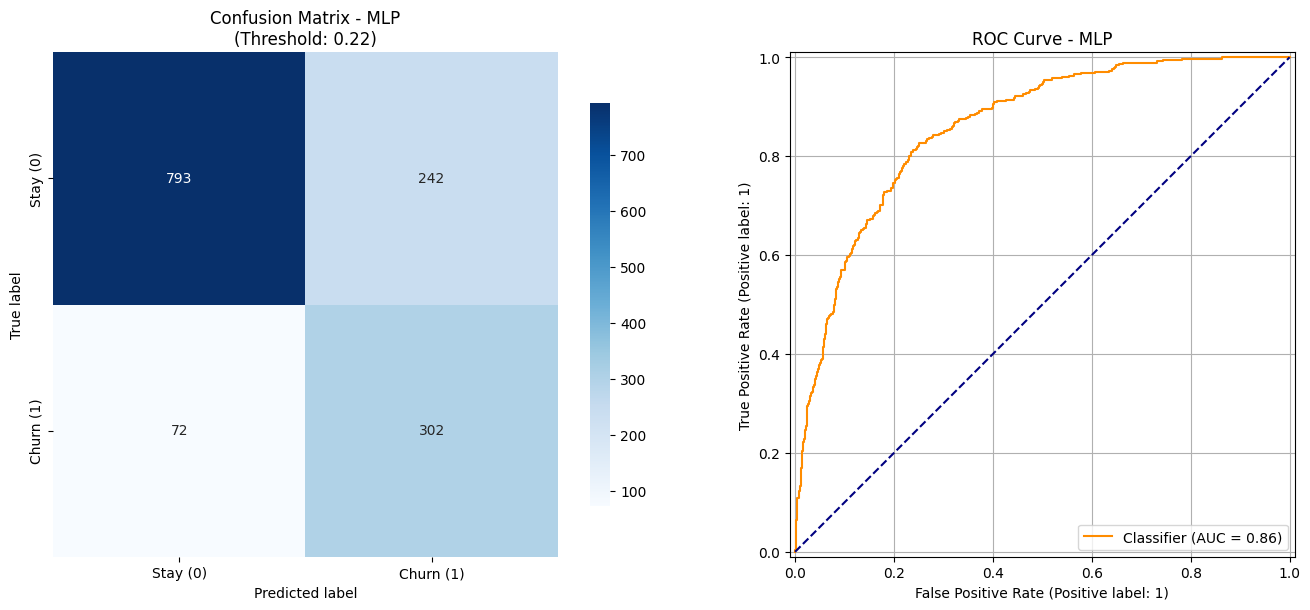

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, RocCurveDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cm = confusion_matrix(y_test, y_pred_adj)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={"shrink": .8},
            xticklabels=['Stay (0)', 'Churn (1)'], 
            yticklabels=['Stay (0)', 'Churn (1)'], ax=ax1)
ax1.set_xlabel('Predicted label')
ax1.set_ylabel('True label')
ax1.set_title(f'Confusion Matrix - MLP\n(Threshold: {best_threshold:.2f})')

RocCurveDisplay.from_predictions(y_test, y_probs, ax=ax2, curve_kwargs={'color': 'darkorange'})
ax2.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax2.set_title('ROC Curve - MLP')
ax2.set_aspect('equal')
ax2.grid(True)

plt.tight_layout()
plt.show()

Wykres macierzy konfuzji pokazuje, że model poprawnie zidentyfikował 302 osoby faktycznie odchodzące oraz 793 lojalnych klientów. Błąd typu II wystąpił w 72 przypadkach, co oznacza, że algorytm skutecznie wyłapuje większość realnych rezygnacji, choć generuje przy tym zauważalną liczbę błędnych wskazań w grupie stabilnych klientów.

Wykres krzywej ROC z wynikiem AUC na poziomie 0.86 potwierdza wysoką skuteczność modelu w rozróżnianiu obu grup użytkowników. Wynik ten wskazuje, że MLP z dużym prawdopodobieństwem poprawnie różnicuje sygnały świadczące o chęci odejścia od zachowań typowych dla osób pozostających w firmie.

## Sieć neuronowa – optymalizacja balansu (F1-score)

#### Wstęp i architektura

Poniższa sekcja prezentuje autorską architekturę głębokiej sieci neuronowej typu Feed-Forward, zaprojektowaną pod kątem precyzyjnej identyfikacji klientów zagrożonych odejściem (churn). Model opiera się na trzech warstwach gęstych (Dense). Kluczowym elementem jest zastosowanie **Batch Normalization**, która stabilizuje proces uczenia, oraz warstw **Dropout** (0.3 i 0.2), które chronią model przed przeuczeniem poprzez losowe wyłączanie neuronów w trakcie treningu. Jako funkcję straty wykorzystano *binary crossentropy*, a nad całością czuwa mechanizm **Early Stopping**, przywracający najlepsze wagi modelu po wykryciu stagnacji błędu na zbiorze walidacyjnym.

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6894 - auc: 0.7249 - loss: 0.6261 - val_accuracy: 0.7870 - val_auc: 0.8339 - val_loss: 0.4530
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7670 - auc: 0.7928 - loss: 0.4939 - val_accuracy: 0.7933 - val_auc: 0.8420 - val_loss: 0.4210
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7755 - auc: 0.8083 - loss: 0.4658 - val_accuracy: 0.8110 - val_auc: 0.8442 - val_loss: 0.4119
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7823 - auc: 0.8161 - loss: 0.4531 - val_accuracy: 0.8110 - val_auc: 0.8456 - val_loss: 0.4085
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7863 - auc: 0.8184 - loss: 0.4510 - val_accuracy: 0.8110 - val_auc: 0.8451 - val_loss: 0.4084
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7888 - auc: 0.8218 - loss: 0.4482 - val_accuracy: 0.8128 - val_auc: 0.8441 - val_loss: 0.4087
Epoch 7/100
141/141 ━━━━━━━━━━━━━━

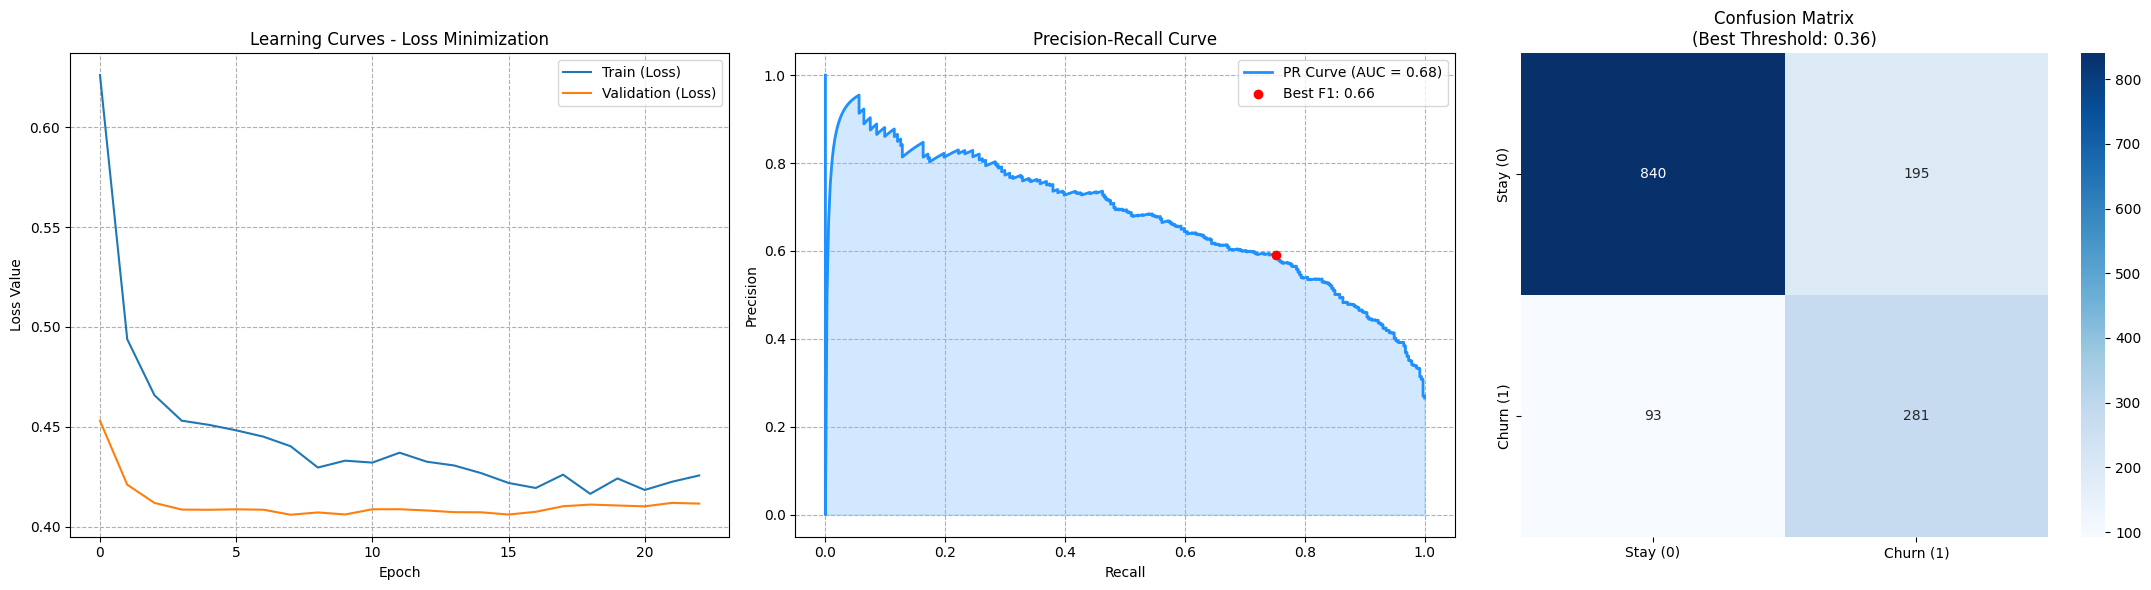

PR AUC Score: 0.6765
Best Threshold: 0.3575

Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1035
           1       0.59      0.75      0.66       374

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.80      1409



In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_keras = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid')
])

model_keras.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model_keras.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

y_probs_keras = model_keras.predict(X_test).flatten()
precision, recall, thresholds = precision_recall_curve(y_test, y_probs_keras)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
pr_auc = auc(recall, precision)

y_pred_keras = (y_probs_keras >= best_threshold).astype(int)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

ax1.plot(history.history['loss'], label='Train (Loss)')
ax1.plot(history.history['val_loss'], label='Validation (Loss)')
ax1.set_title('Learning Curves - Loss Minimization')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss Value')
ax1.legend()
ax1.grid(True, linestyle='--')

ax2.plot(recall, precision, color='dodgerblue', lw=2, label=f'PR Curve (AUC = {pr_auc:.2f})')
ax2.fill_between(recall, precision, alpha=0.2, color='dodgerblue')
ax2.scatter(recall[best_idx], precision[best_idx], color='red', zorder=5, 
            label=f'Best F1: {max(f1_scores):.2f}')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True, linestyle='--')

cm_keras = confusion_matrix(y_test, y_pred_keras)
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Stay (0)', 'Churn (1)'], yticklabels=['Stay (0)', 'Churn (1)'])
ax3.set_title(f'Confusion Matrix\n(Best Threshold: {best_threshold:.2f})')

plt.tight_layout()
plt.show()

print(f"PR AUC Score: {pr_auc:.4f}")
print(f"Best Threshold: {best_threshold:.4f}")
print("\nReport:")
print(classification_report(y_test, y_pred_keras))

Głównym założeniem tej konfiguracji było znalezienie **optymalnego progu decyzyjnego (Best Threshold)**, który maksymalizuje wskaźnik F1, zamiast polegania na domyślnym progu 0.5.

* **PR AUC (0.68):** Wysoka wartość pola pod krzywą Precision-Recall potwierdza, że model skutecznie rozróżnia klasy nawet przy ich nierównomiernym rozkładzie.
* **Recall (0.75):** Dzięki optymalizacji progu do poziomu ok. **0.36**, sieć poprawnie identyfikuje aż **75%** wszystkich klientów, którzy faktycznie zrezygnowali z usług.
* **F1-Score (0.66):** Wynik ten świadczy o doskonałym balansie – model wyłapuje większość odejść, utrzymując precyzję na poziomie **0.59**, co pozwala uniknąć nadmiarowych kosztów związanych z fałszywymi alarmami.

## Sieć neuronowa – maksymalizacja Accuracy i stabilności

#### Wstęp i architektura

Druga konfiguracja to model nastawiony na uzyskanie jak najwyższej ogólnej trafności przewidywań (**Accuracy**). Architektura została rozszerzona do 160 i 64 neuronów w warstwach ukrytych, aby zwiększyć pojemność informacyjną sieci. Wprowadzono zaawansowane techniki optymalizacji:
- **Label Smoothing (0.1):** Technika wygładzania etykiet, która zapobiega nadmiernej pewności siebie modelu i poprawia generalizację.
- **ReduceLROnPlateau:** Mechanizm dynamicznie zmniejszający tempo uczenia (Learning Rate) w momencie, gdy progres minimalizacji błędu zwalnia, co pozwala na niezwykle precyzyjne dostrojenie wag.

Epoch 1/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6984 - loss: 0.6465 - val_accuracy: 0.7360 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 2/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7623 - loss: 0.5487 - val_accuracy: 0.7928 - val_loss: 0.4886 - learning_rate: 0.0010
Epoch 3/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7733 - loss: 0.5263 - val_accuracy: 0.8084 - val_loss: 0.4731 - learning_rate: 0.0010
Epoch 4/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7804 - loss: 0.5135 - val_accuracy: 0.8112 - val_loss: 0.4737 - learning_rate: 0.0010
Epoch 5/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7872 - loss: 0.5018 - val_accuracy: 0.8098 - val_loss: 0.4750 - learning_rate: 0.0010
Epoch 6/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7835 - loss: 0.5017 - val_accuracy: 0.8027 - val_loss: 0.4757 - learning_rate: 0.0010
Epoch 7/120
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7913 - loss: 0.

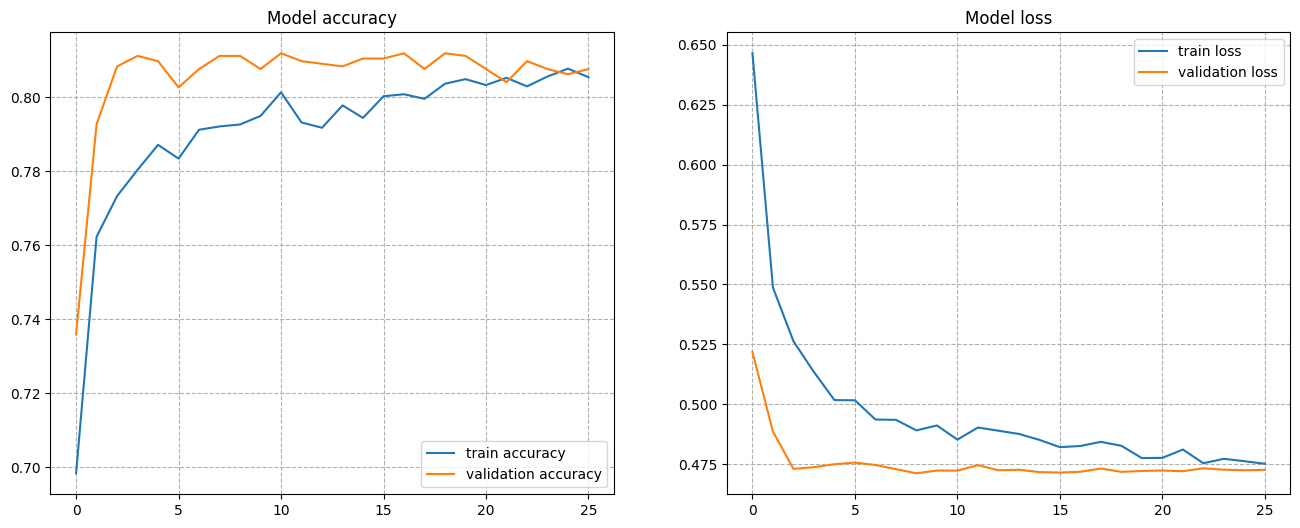

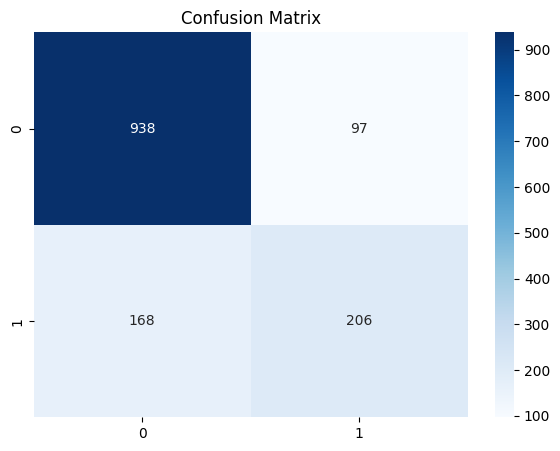

Accuracy: 0.8119
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1035
           1       0.68      0.55      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [31]:
input_dim = X_train.shape[1]
model_final = Sequential([
    Input(shape=(input_dim,)),
    
    Dense(160, activation='relu'), 
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

model_final.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1), 
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
]


history = model_final.fit(
    X_train, y_train, 
    epochs=120, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

y_probs = model_final.predict(X_test).flatten()
y_pred = (y_probs >= 0.50).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(history.history['accuracy'], label='train accuracy')
ax1.plot(history.history['val_accuracy'], label='validation accuracy')
ax1.set_title('Model accuracy')
ax1.legend()
ax1.grid(True, linestyle='--')

ax2.plot(history.history['loss'], label='train loss')
ax2.plot(history.history['val_loss'], label='validation loss')
ax2.set_title('Model loss')
ax2.legend()
ax2.grid(True, linestyle='--')
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Ten model kładzie większy nacisk na poprawność każdego pojedynczego wskazania churnu.

* **Accuracy (0.81):** Model osiąga najwyższą ogólną trafność przewidywań (81%), co oznacza bardzo rzadkie pomyłki w klasyfikacji klientów zostających (Stay).
* **Precision (0.68):** W porównaniu do poprzedniej wersji, ten model znacznie rzadziej wskazuje odejście klienta w sposób błędny. Jest bardziej "ostrożny" i pewny swoich decyzji.
* **Recall (0.55):** Wyższa precyzja została uzyskana kosztem czułości – model wyłapuje nieco ponad połowę faktycznych odejść, ale robi to z większą pewnością niż model pierwszy.